In [1]:
import numpy as np
from helper_functions import phase_diff as pd
import matplotlib.pyplot as plt

In [2]:
from importlib import reload
def reload_protocols():
    reload(pd)

## CS

## Produce data

In [ ]:
sigmas = [0]

alpha_grid = np.linspace(0, np.sqrt(2), 40)
num_samples = 10000

for i, sigma in enumerate(sigmas):

    p_err_cs = pd.perr_cs(alpha_grid, sigma, num_samples)

    print(f"\rProgress: {i+1}/{len(sigmas)}", end="", flush=True)

    np.savez(f"data/phase_diff/perr_data_phase_diff_cs_a{len(alpha_grid)}_S{num_samples}_sigma{sigma}.npz", alpha_grid = alpha_grid, p_err_cs = p_err_cs, sigma = sigma)

## Load data

In [ ]:
data = np.load(f"data/phase_diff/perr_data_phase_diff_cs_a40_S3000_sigma0.1.npz")

alpha_cs = data["alpha_grid"]
p_err_cs = data["p_err_cs"]
sigma_cs = data["sigma"]

## DSS

## Produce data

In [ ]:
# Parameters
N = np.linspace(0, 2.0, 40)
beta = np.linspace(0.0, 1.0, 40)

num_samples = 10000

for sigma in [0.65, 0.75]:

    print(f"\n σ = {sigma}")
    
    # Compute error probabilities
    p_err_dss = pd.perr_dss(N, beta, sigma, num_samples)
    # Create meshgrid for plotting
    N_grid, beta_grid = np.meshgrid(N, beta, indexing="ij")
    #save data
    np.savez(f"data/phase_diff/perr_data_phase_diff_dss_N{len(N)}_b{len(beta)}_S{num_samples}_sigma{sigma}.npz", N=N, beta = beta, p_err_dss=p_err_dss, sigma = sigma)


## Load data

In [ ]:
data = np.load(f"data/perr_data_phase_diff_dss_N40_b40_S10000_sigma0.1.npz")

N_dss = data["N"]
beta_dss = data["beta"]
p_err_dss = data["p_err_dss"]
sigma_dss = data["sigma"]

## Plot data and Theory

In [3]:
reload_protocols()
sigmas = [0.1]
colors_light = [ "#e9f063",  "#d62728",  "#2ca02c",  "#ff7f0e",  "#9467bd",  "#17becf",  "#e377c2",  "#8c564b",  "#bcbd22",  "#7f7f7f",  "#5af74b"]*2
colors_dark = ["#8E9C09",  "#6F3434",  "#084108",  "#773b05",  "#460880",  "#0c6f7c",  "#5c0642",  "#941c04",  "#8b8b06",  "#212121",  "#092a06",  "#092a06"]*2
pd.plot_homodyne_perr(sigmas, colors_light, colors_dark, dss = 'all', cs = 'all')

0.8925687358314575


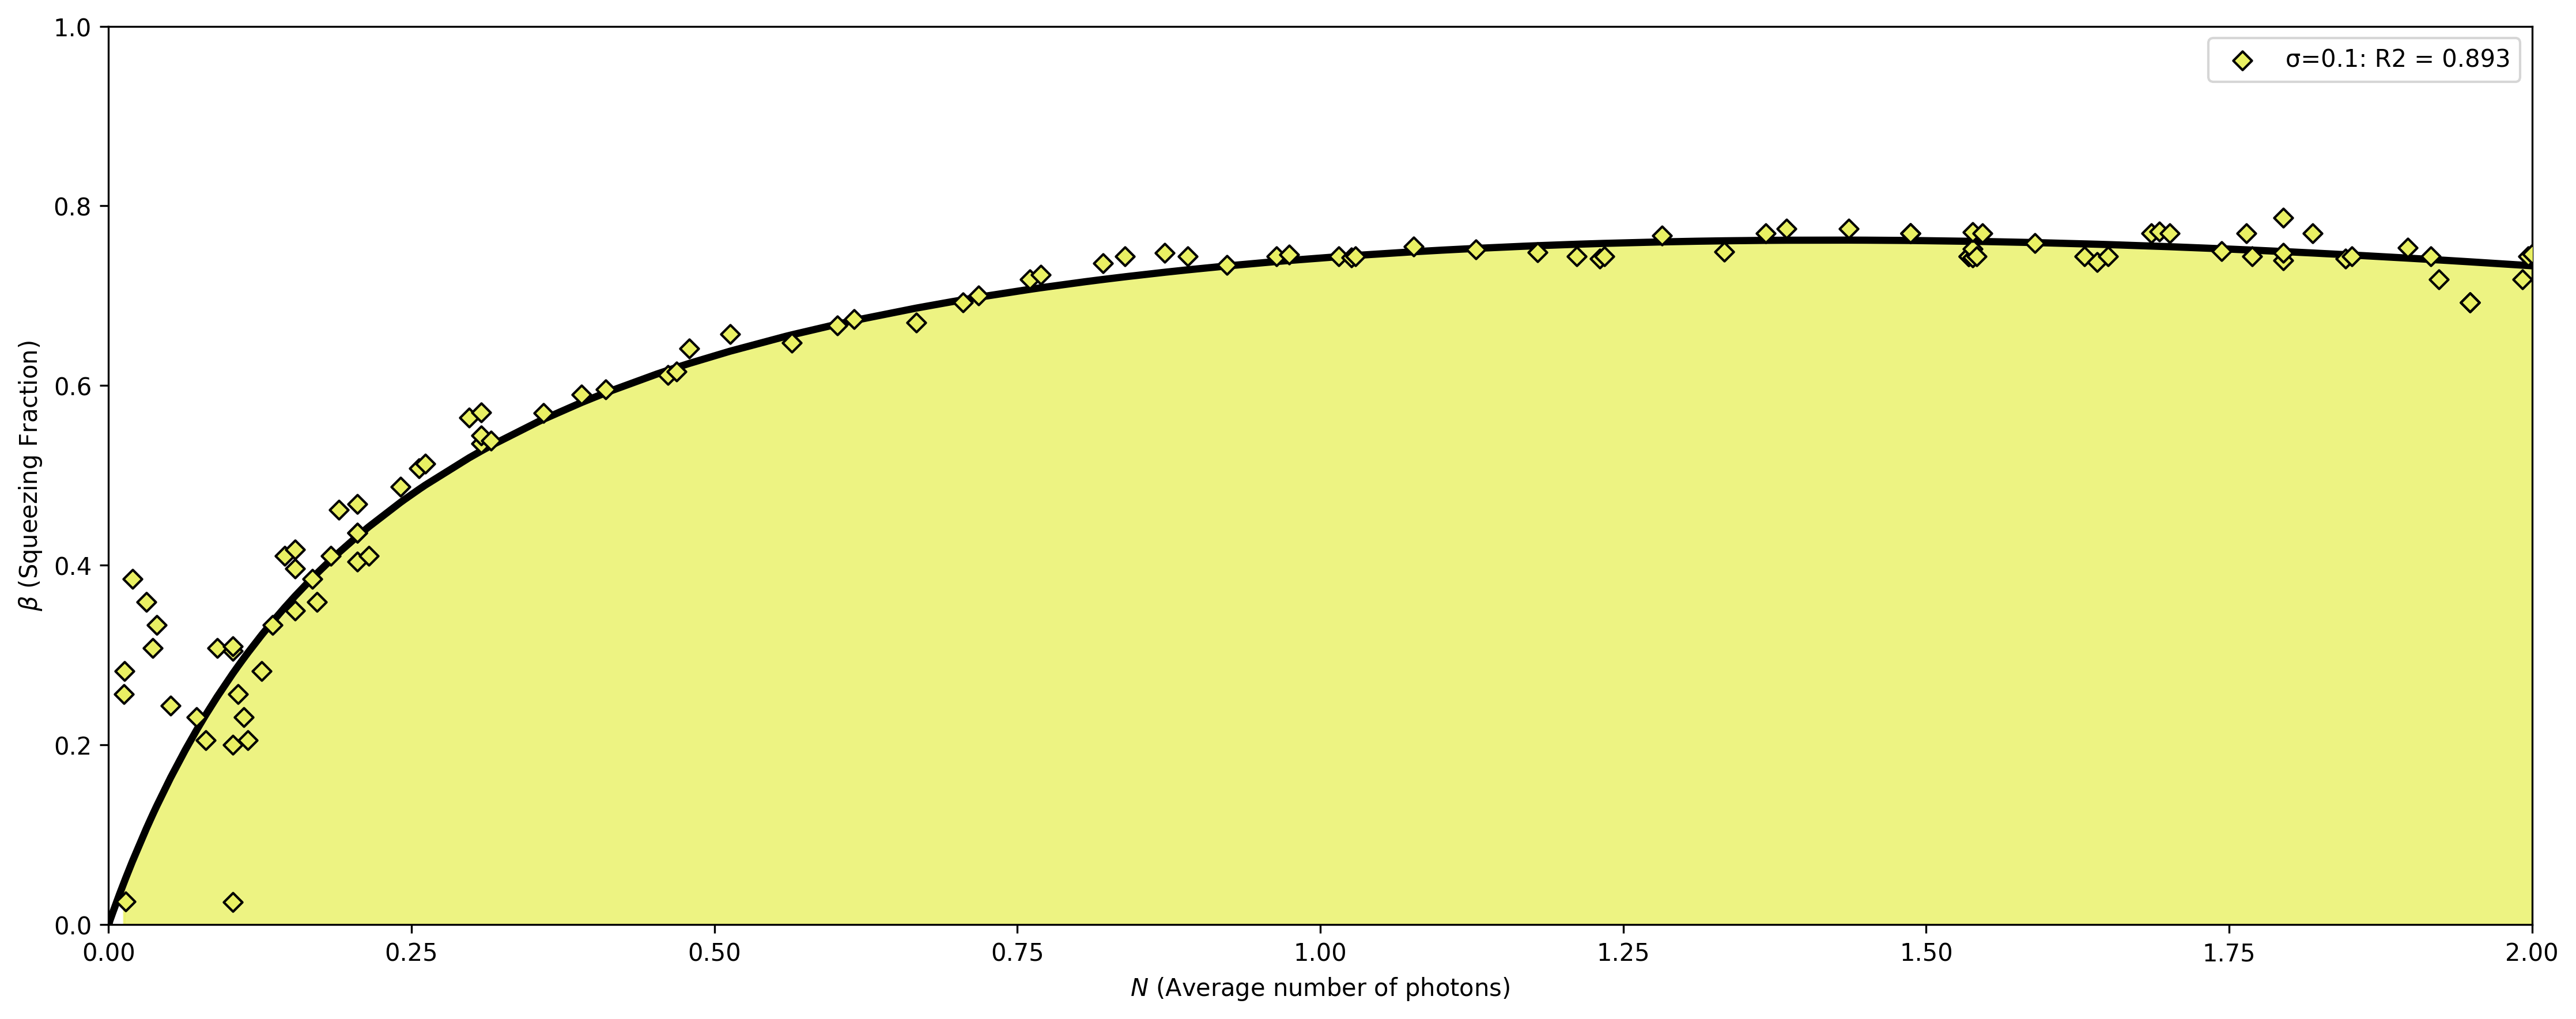

In [49]:
reload_protocols()
sigmas = [0.1]
colors_th = [ "#e9f063",  "#d62728",  "#2ca02c",  "#ff7f0e",  "#9467bd",  "#17becf",  "#e377c2",  "#8c564b",  "#bcbd22",  "#7f7f7f",  "#5af74b"]*2
colors_opt = ["#8E9C09",  "#6F3434",  "#084108",  "#773b05",  "#460880",  "#0c6f7c",  "#5c0642",  "#941c04",  "#8b8b06",  "#212121",  "#092a06",  "#092a06"]*2
beta_opt_dict = pd.optimal_squeezing(sigmas, colors_opt, colors_th, opt = False, th = True)